In [39]:
import cv2
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import torch

## Animal Segmentation

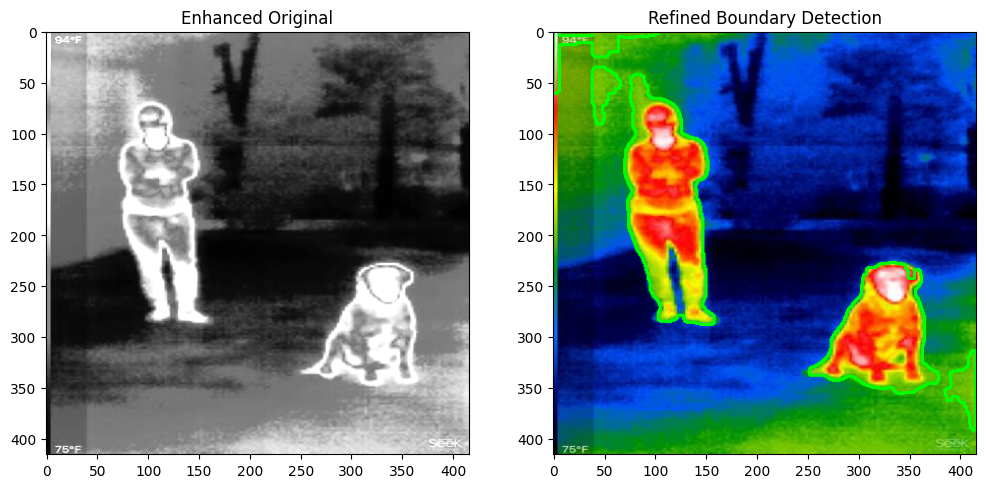

In [22]:
# 1. Load the Thermal Image
url = "https://transform.roboflow.com/Ly2DeBzbwsemGd2ReHk4BFxy8683/34c0c756031f3cf84c3d52d06431f79e/transformed.jpg"
response = requests.get(url)
img_array = np.array(Image.open(BytesIO(response.content)))
image = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

# 2. Pre-processing: Focus on Heat Intensity
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Increase contrast to make the "hot" objects stand out more
alpha = 1.5 # Contrast control
beta = 0    # Brightness control
adjusted = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)

# Use a larger blur kernel to smooth out sensor noise
blurred = cv2.medianBlur(adjusted, 7)

# 3. Improved Thresholding
# Instead of Otsu, we use a fixed high threshold or Adaptive Threshold
# to capture only the 'hottest' pixels (the subjects)
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)

# 4. Refine the Mask
# Dilate to connect broken parts of the body, then Erode to clean edges
kernel = np.ones((5,5), np.uint8)
refined = cv2.dilate(thresh, kernel, iterations=2)
refined = cv2.erode(refined, kernel, iterations=1)

# 5. Find and Filter Contours
contours, _ = cv2.findContours(refined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result_img = image.copy()
for cnt in contours:
    # Filter by area: ignore tiny noise dots and massive background chunks
    area = cv2.contourArea(cnt)
    if 500 < area < 50000: 
        # Optional: Filter by bounding box aspect ratio to find 'organic' shapes
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w)/h
        
        # Human/Animal figures usually aren't perfect squares or long thin lines
        if 0.2 < aspect_ratio < 5.0:
            cv2.drawContours(result_img, [cnt], -1, (0, 255, 0), 2)

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Enhanced Original")
plt.imshow(cv2.cvtColor(adjusted, cv2.COLOR_GRAY2RGB))
plt.subplot(1, 2, 2)
plt.title("Refined Boundary Detection")
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.show()

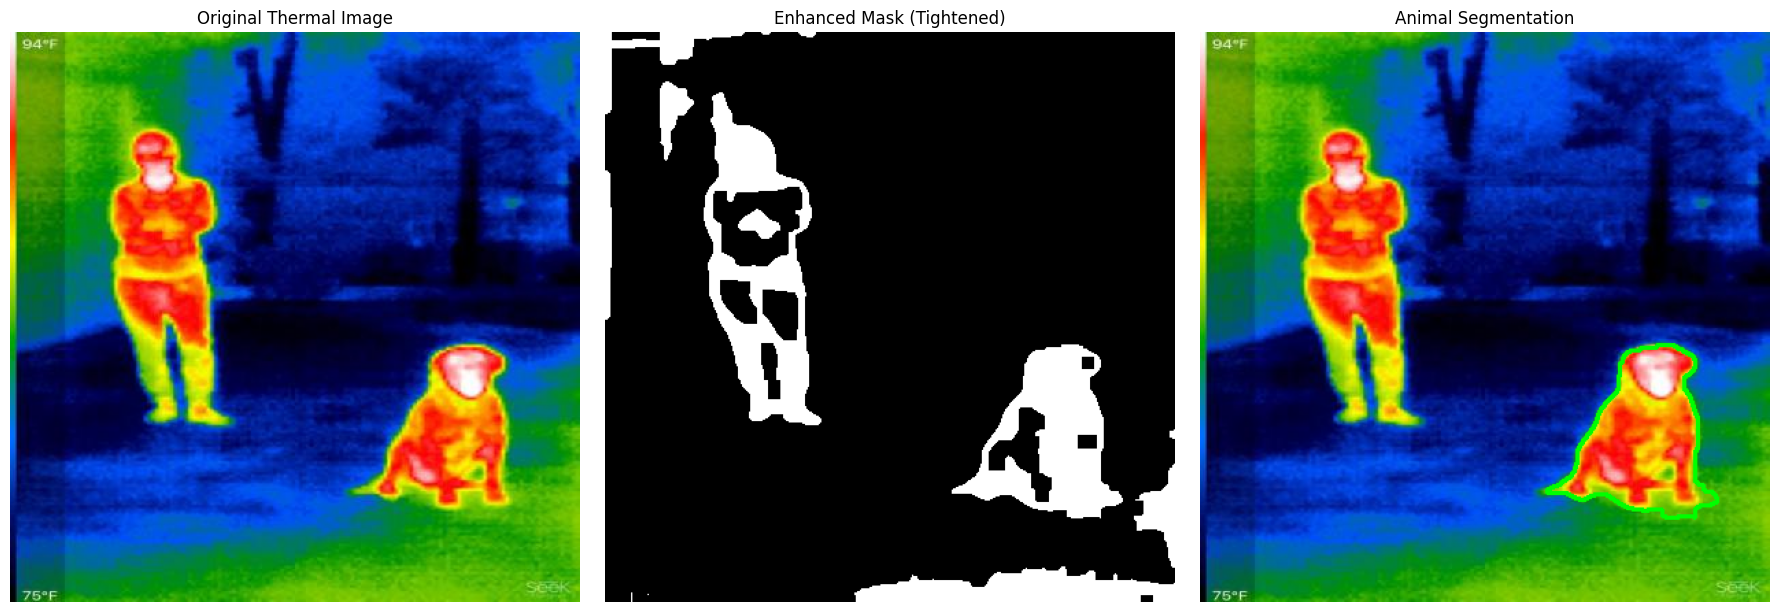

In [27]:
import cv2
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# 1. Load the Thermal Image
url = "https://transform.roboflow.com/Ly2DeBzbwsemGd2ReHk4BFxy8683/34c0c756031f3cf84c3d52d06431f79e/transformed.jpg"
response = requests.get(url)
img_array = np.array(Image.open(BytesIO(response.content)))
image = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

# 2. Pre-processing
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Increase contrast
alpha = 1.5 
beta = 0    
adjusted = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)

# IMPROVEMENT 1: Reduce blur kernel size slightly (7 -> 5)
# A large kernel blurs the edges too much, making the object look bigger than it is.
blurred = cv2.medianBlur(adjusted, 5)

# 3. Thresholding
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)

# 4. Refine the Mask (IMPROVEMENT 2: Better Morphology)
# Instead of dilate(2) -> erode(1) which expands the object, 
# we use MORPH_CLOSE. This performs Dilation then Erosion with the same strength.
# It fills small black holes inside the white object (cool spots on the dog) 
# but respects the original outer boundary.
kernel = np.ones((5,5), np.uint8)
refined = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

# 5. Find and Filter Contours
contours, _ = cv2.findContours(refined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result_img = image.copy()
img_height, img_width = image.shape[:2]

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w)/h
    area = cv2.contourArea(cnt)

    if x < 5 and y < 5:
        continue

    # Filter 1: Area
    if 1000 < area < 50000: 
        
        # Filter 2: Shape/Aspect Ratio
        # Dog: ~0.8 - 1.2
        if 0.5 < aspect_ratio < 2.0:
                
            # Draw the contour
            # Using a slightly thinner line (2px) for cleaner look
            cv2.drawContours(result_img, [cnt], -1, (0, 255, 0), 2)

# 6. Visualization
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Original Thermal Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Enhanced Mask (Tightened)")
plt.imshow(refined, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Animal Segmentation")
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()